In [1]:
# AG News Logistic Regression Notebook
# ===================================

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from data_loader import load_ag_news
from preprocessing import preprocess_dataframe
from feature_extraction import build_bigram_vocab, vectorize_dataframe_sparse
from logistic_regression_scratch import LogisticRegressionScratch
from evaluation import confusion_matrix, precision_recall_f1

# sklearn imports
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import confusion_matrix as sk_confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

In [2]:
# Load and preprocess data
train_df, test_df = load_ag_news()
train_df = preprocess_dataframe(train_df)
test_df = preprocess_dataframe(test_df)

print("Training samples:", len(train_df))
print("Test samples:", len(test_df))

Training samples: 120000
Test samples: 7600


In [5]:
# Build bigram vocabulary and vectorize
# Build bigram vocabulary
bigram_to_idx = build_bigram_vocab(train_df['tokens'])

# Vectorize with sparse matrix (much faster)
X_train = vectorize_dataframe_sparse(train_df, bigram_to_idx)
X_test = vectorize_dataframe_sparse(test_df, bigram_to_idx)

y_train = train_df['label'].values - 1  # Convert to 0-based indexing
y_test = test_df['label'].values - 1   # Convert to 0-based indexing

print("Feature dimension:", X_train.shape[1])

Feature dimension: 1216541


In [6]:
# Train Logistic Regression from scratch
model_scratch = LogisticRegressionScratch(input_dim=X_train.shape[1], num_classes=4, lr=0.5)
model_scratch.fit(X_train, y_train, epochs=5, batch_size=64)

# Predict
y_pred_scratch = model_scratch.predict(X_test)

In [8]:
# Evaluate from-scratch model
cm_scratch = confusion_matrix(y_test, y_pred_scratch, num_classes=4)
precision, recall, f1, p_macro, r_macro, f_macro = precision_recall_f1(cm_scratch)

print("From Scratch Confusion Matrix:\n", cm_scratch)
print(f"Macro Precision: {p_macro:.4f}, Macro Recall: {r_macro:.4f}, Macro F1: {f_macro:.4f}")

From Scratch Confusion Matrix:
 [[1672   66   70   92]
 [  35 1813   19   33]
 [  72   38 1566  224]
 [  48   38  121 1693]]
Macro Precision: 0.8883, Macro Recall: 0.8874, Macro F1: 0.8872


In [9]:
# Train Logistic Regression with scikit-learn
clf = LogisticRegression(max_iter=500)
clf.fit(X_train, y_train)
y_pred_sklearn = clf.predict(X_test)

# Confusion matrix & metrics
cm_sklearn = sk_confusion_matrix(y_test, y_pred_sklearn)
p_sklearn = precision_score(y_test, y_pred_sklearn, average=None)
r_sklearn = recall_score(y_test, y_pred_sklearn, average=None)
f_sklearn = f1_score(y_test, y_pred_sklearn, average=None)

print("Sklearn Confusion Matrix:\n", cm_sklearn)
print(f"Sklearn Macro Precision: {precision_score(y_test, y_pred_sklearn, average='macro'):.4f}")
print(f"Sklearn Macro Recall: {recall_score(y_test, y_pred_sklearn, average='macro'):.4f}")
print(f"Sklearn Macro F1: {f1_score(y_test, y_pred_sklearn, average='macro'):.4f}")

Sklearn Confusion Matrix:
 [[1684   64   75   77]
 [  30 1825   22   23]
 [  63   28 1614  195]
 [  45   28  135 1692]]
Sklearn Macro Precision: 0.8971
Sklearn Macro Recall: 0.8967
Sklearn Macro F1: 0.8966


In [10]:
# Comparison Table
comparison = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-score"],
    "From Scratch Macro": [p_macro, r_macro, f_macro],
    "Sklearn Macro": [
        precision_score(y_test, y_pred_sklearn, average='macro'),
        recall_score(y_test, y_pred_sklearn, average='macro'),
        f1_score(y_test, y_pred_sklearn, average='macro')
    ]
})
comparison

,Metric,From Scratch Macro,Sklearn Macro
0,Precision,0.888343,0.897105
1,Recall,0.887368,0.896711
2,F1-score,0.887200,0.896622


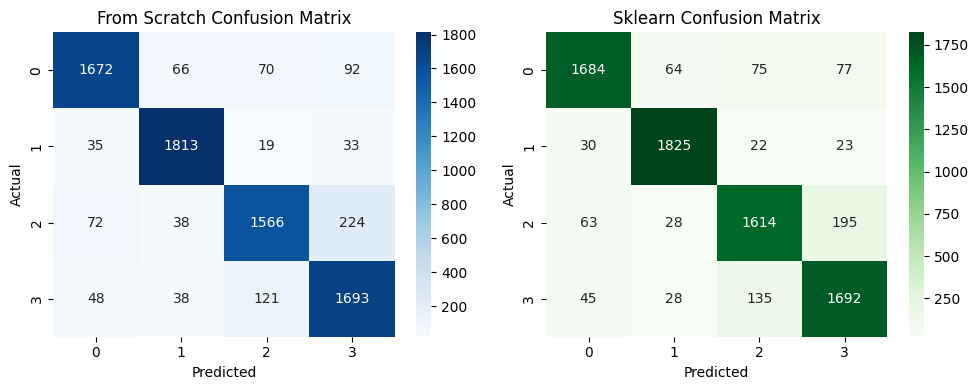

In [11]:
# Visual comparison

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.heatmap(cm_scratch, annot=True, fmt="d", cmap="Blues")
plt.title("From Scratch Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1,2,2)
sns.heatmap(cm_sklearn, annot=True, fmt="d", cmap="Greens")
plt.title("Sklearn Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()